In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('scores_data.csv')

In [3]:
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [4]:
df.tail()

,Batch,User_ID,Score
144,AI_ELITE_4,uid_5,4 / 7
145,AI_ELITE_4,uid_4,4 / 7
146,AI_ELITE_4,uid_3,4 / 7
147,AI_ELITE_4,uid_2,3 / 7
148,AI_ELITE_4,uid_1,2 / 7


In [5]:
df.describe()

,Batch,User_ID,Score
count,149,149,149
unique,3,149,8
top,AI_ELITE_7,uid_149,4 / 7
freq,53,1,40


In [6]:
df.isnull().sum()

Batch          0
User_ID        0
   Score       0
dtype: int64

In [7]:
df.columns

Index(['Batch ', 'User_ID ', '   Score   '], dtype='object')

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df['Batch'].nunique()

3

In [10]:
df['Numerical_score'] = df['Score'].str.split('/').str[0].astype(int)

In [11]:
df.head()

,Batch,User_ID,Score,Numerical_score
0,AI_ELITE_7,uid_149,6 / 7,6
1,AI_ELITE_7,uid_148,6 / 7,6
2,AI_ELITE_7,uid_147,7 / 7,7
3,AI_ELITE_7,uid_146,7 / 7,7
4,AI_ELITE_7,uid_145,4 / 7,4


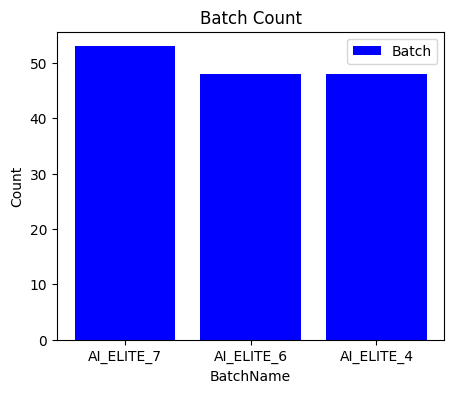

In [12]:
plt.figure(figsize = (5,4))
plt.bar(df['Batch'].value_counts().index,df['Batch'].value_counts().values,label = "Batch",color = 'blue')
plt.title("Batch Count")
plt.xlabel('BatchName')
plt.ylabel('Count')
plt.legend()
plt.show()

In [13]:
score_frequencies = df['Numerical_score'].value_counts().sort_index()

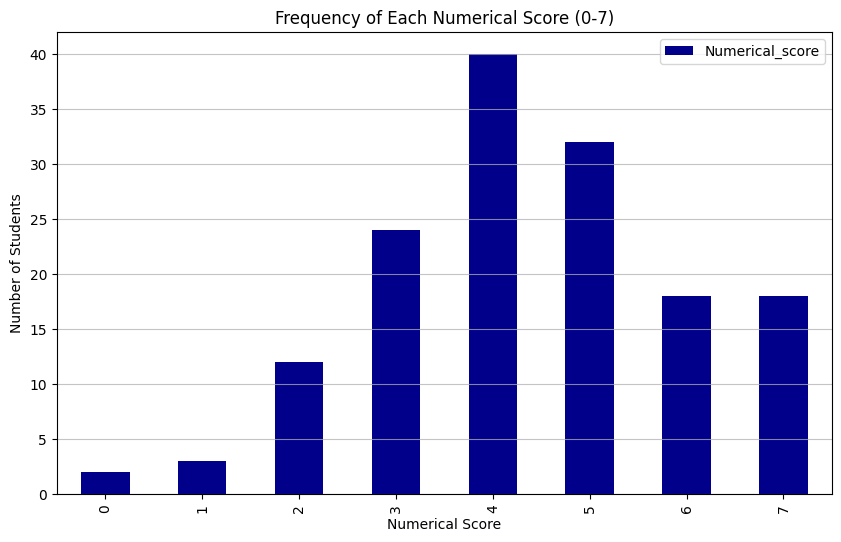

In [14]:
plt.figure(figsize=(10, 6))
score_frequencies.plot(kind='bar', color='darkblue',label = 'Numerical_score')
plt.title('Frequency of Each Numerical Score (0-7)')
plt.xlabel('Numerical Score')
plt.ylabel('Number of Students')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()


In [15]:
avg = df.groupby('Batch')['Numerical_score'].mean()

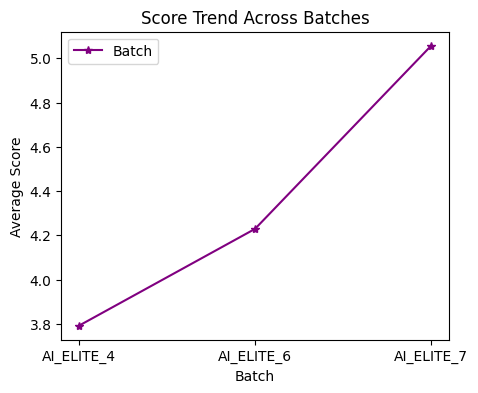

In [16]:
plt.figure(figsize=(5,4))
plt.plot(avg.index, avg.values,
         marker='*', linestyle='-',
         color='purple',label = 'Batch')

plt.xlabel('Batch')
plt.ylabel('Average Score')
plt.legend()
plt.title('Score Trend Across Batches')
plt.show()

C:\Users\RAGIPALLY AVANTHI\AppData\Local\Temp\ipykernel_1192\946418441.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


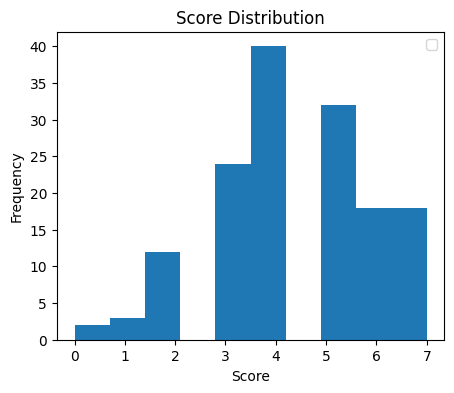

In [17]:
plt.figure(figsize=(5,4))
plt.hist(df['Numerical_score'],
         bins=10,)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Score Distribution')
plt.legend()
plt.show()

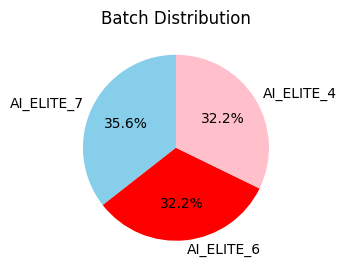

In [18]:
counts = df['Batch'].value_counts()

plt.figure(figsize=(3,4))
plt.pie(counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['skyblue','red','pink'])

plt.title('Batch Distribution')
plt.show()

In [19]:
pd.pivot_table(df,values = 'Numerical_score',
              index = 'Batch',
              aggfunc = ['mean','median','max'])

,mean,median,max
,Numerical_score,Numerical_score,Numerical_score
Batch,,,
AI_ELITE_4,3.791667,4.0,7
AI_ELITE_6,4.229167,4.0,7
AI_ELITE_7,5.056604,5.0,7
